In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import display
from matplotlib import pyplot as plt

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analogues import AnalogueSample, FilterConfig, SelectionConfig
from config.loader import load_config

print("Repo root:", repo_root)

def resolve_base_path(repo_root: Path) -> str:
    raw_candidates = [
        os.environ.get("TNG_BASE_PATH"),
        os.environ.get("ILLUSTRIS_BASE_PATH"),
        str(repo_root / "tng300" / "outputs"),
    ]

    for raw in raw_candidates:
        if not raw:
            continue
        base = Path(raw).expanduser()
        for candidate in (base, base / "tng300" / "outputs"):
            if (candidate / "groups_099").exists():
                return str(candidate.resolve())

    raise FileNotFoundError(
        "Could not find a valid TNG outputs directory. Set TNG_BASE_PATH or ILLUSTRIS_BASE_PATH "
        "to the outputs directory, or to a root that contains tng300/outputs."
    )


config_loader = load_config()
analysis_config = config_loader.get_config()

base_path = resolve_base_path(repo_root)
snap = 99
print("Using base_path:", base_path)

selection_config = SelectionConfig(**analysis_config.selection)
filter_config = FilterConfig(**analysis_config.filter)

print("Selection config loaded from config/config.json:")
display(pd.DataFrame([analysis_config.selection]))
print("Filter config loaded from config/config.json:")
display(pd.DataFrame([analysis_config.filter]))
print("Active features in shared config:", list(analysis_config.features))
print("Active target in shared config:", analysis_config.target_name)

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=selection_config,
    filter_config=filter_config,
    verbose=True,
    snap=snap,
    catalog_c_path=os.path.abspath("../tng300/catalog_c/stellar_circs.hdf5")
)

Repo root: C:\Users\Sami\Desktop\dsp-cosmology
Using base_path: C:\Users\Sami\Desktop\dsp-cosmology\tng300\outputs
Selection config loaded from config/config.json:


,m_stellar_min,m_stellar_max,r_min,r_max,blue_threshold_gr,disc_threshold
0,2.000000e+10,5.000000e+11,500.0,1000.0,0.68,0.1


Filter config loaded from config/config.json:


,v_tot_min,v_tot_max,vt_min,vt_max,vr_min,vr_max,density_radius,intruder_factor,third_massive_factor
0,0,600,0,300,-400,0,2000,0.5,1.5


Active features in shared config: ['r_kpc', 'v_r', 'v_t', 'mstar_big', 'mstar_small']
Active target in shared config: total_virial_mass

[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼─────────

In [28]:
# Based on https://academic.oup.com/mnras/article/535/2/1721/7760400
# Milky way values
mw = {
        'Mass': 5e10,
        'e': 0.52, # With AI from https://arxiv.org/pdf/2303.16217
        #'minor-major-ratio': 0.71, # https://www.physics.usyd.edu.au/~jbh/S/ARAA_2016.pdf
        'minor-major-ratio': 0.31, # https://iopscience.iop.org/article/10.3847/1538-3881/ac9900
        'intermediate-major-ratio': 0.44, # https://iopscience.iop.org/article/10.3847/1538-3881/ac9900
        'minor-intermediate-ratio': 0.1,
        'g-r': 0.52 # From Abeers Photometry_Analysis_central+largest-satellite-v2.ipynb
     }

# M31 values
m31 = {
        'Mass': 12e10,
        'e': 0.37, # https://academic.oup.com/mnras/article/481/3/3210/5078394
        'minor-major-ratio': 0.1,
        'intermediate-major-ratio': 0.1,
        'minor-intermediate-ratio': 0.1,
        'g-r': 0.62 # From Abeers Photometry_Analysis_central+largest-satellite-v2.ipynb
      }

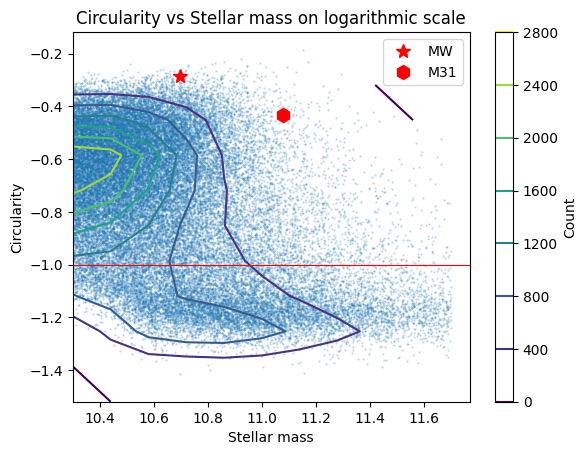

In [ ]:
x = np.log10(analogue_sample._sample.m_stellar)
y = np.log10(analogue_sample._sample.circ)
plt.figure()
plt.plot(x, y, ".", markersize=1.0, alpha=0.3)

# Countour
H, xedges, yedges = np.histogram2d(x, y, bins=10, density=False)
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
plt.contour(X, Y, H.T, levels=7)

# Milky Way
plt.plot(np.log10(mw['Mass']), np.log10(mw['e']), "*", markersize=10, alpha=1, label='MW', color='red')

# M31
plt.plot(np.log10(m31['Mass']), np.log10(m31['e']), "h", markersize=10, alpha=1, label='M31', color='red')

# Classification cutoff point
plt.axhline(np.log10(0.1),color='red',linewidth=0.8) # y = 0

plt.colorbar(label='Count')
plt.xlabel("Stellar mass")
plt.ylabel("Circularity")
plt.title("Circularity vs Stellar mass on logarithmic scale")
plt.legend()
plt.show()

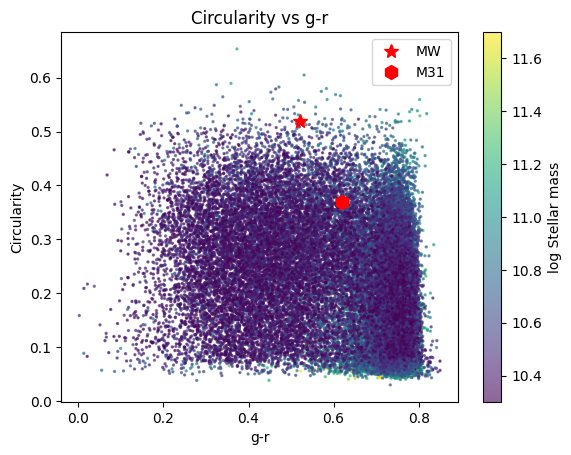

In [ ]:
g_r = analogue_sample._sample.g_band - analogue_sample._sample.r_band
m_stellar = analogue_sample._sample.m_stellar
circ = analogue_sample._sample.circ
plt.figure()
scatter = plt.scatter(g_r, circ, c=np.log10(m_stellar), s=2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='log Stellar mass')

# Milky Way
plt.plot(mw['g-r'], mw['e'], "*", markersize=10, alpha=1, label='MW', color='red')
# M31
plt.plot(m31['g-r'], m31['e'], "h", markersize=10, alpha=1, label='M31', color='red')

plt.xlabel("g-r")
plt.ylabel("Circularity")
plt.title("Circularity vs g-r")
plt.legend()
plt.show()

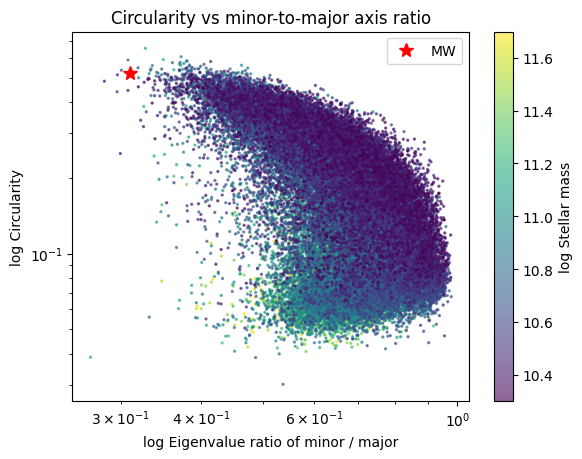

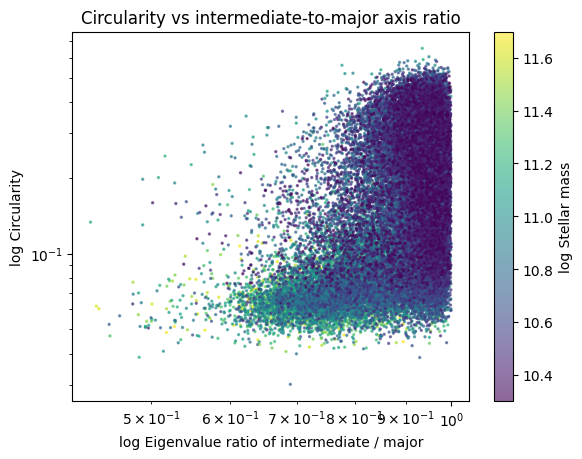

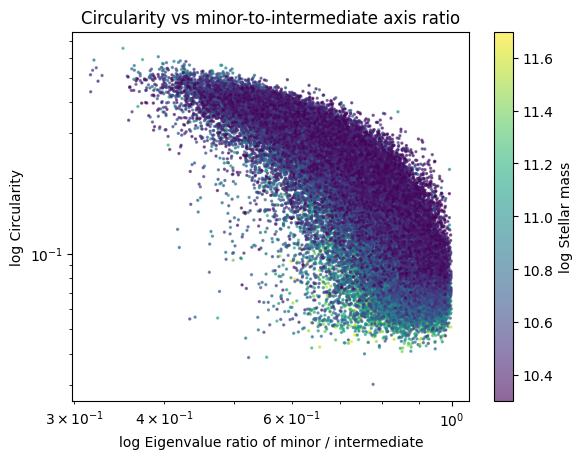

In [36]:
# MassTensorEigenVals ratios with M3 / M1 being the ratio
eig1 = analogue_sample._sample.eigen[:,0]
eig2 = analogue_sample._sample.eigen[:,1]
eig3 = analogue_sample._sample.eigen[:,2]
m_stellar = analogue_sample._sample.m_stellar
circ = analogue_sample._sample.circ

plt.figure()
scatter = plt.scatter(eig1 / eig3, circ, c=np.log10(m_stellar), s=2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='log Stellar mass')
# Milky Way
plt.plot(mw['minor-major-ratio'], mw['e'], "*", markersize=10, alpha=1, label='MW', color='red')
# M31
#plt.plot(m31['intermediate-major-ratio'], m31['e'], "h", markersize=10, alpha=1, label='M31', color='red')
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log Eigenvalue ratio of minor / major")
plt.ylabel("log Circularity")
plt.title("Circularity vs minor-to-major axis ratio")



plt.figure()
scatter = plt.scatter(eig2 / eig3, circ, c=np.log10(m_stellar), s=2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='log Stellar mass')
# Milky Way
#plt.plot(mw['intermediate-major-ratio'], mw['e'], "*", markersize=10, alpha=1, label='MW', color='red')
# M31
#plt.plot(m31['intermediate-major-ratio'], m31['e'], "h", markersize=10, alpha=1, label='M31', color='red')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log Eigenvalue ratio of intermediate / major")
plt.ylabel("log Circularity")
plt.title("Circularity vs intermediate-to-major axis ratio")
#plt.legend()



plt.figure()
scatter = plt.scatter(eig1 / eig2, circ, c=np.log10(m_stellar), s=2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='log Stellar mass')
# Milky Way
#plt.plot(mw['minor-intermediate-ratio'], mw['e'], "*", markersize=10, alpha=1, label='MW', color='red')
# M31
#plt.plot(m31['minor-intermediate-ratio'], m31['e'], "h", markersize=10, alpha=1, label='M31', color='red')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log Eigenvalue ratio of minor / intermediate")
plt.ylabel("log Circularity")
plt.title("Circularity vs minor-to-intermediate axis ratio")
plt.show()